In [28]:
from typing import Tuple
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import MNIST
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output

---

Ниже представлена готовая функция для загрузки и предварительной обработки данных.
В рамках этой функции мы выполняем следующие шаги.
* Загрузка исходных данных.
* Сохранение **10 000** изображений в качестве обучающей выборки.
* Сжатие изображений в два раза по каждой из осей, что приводит к размеру **14x14**..
* Растягиваем изображение размером **14x14** в вектор длиной $14 \cdot 14 = 196$.

In [29]:
def load_mnist(
    train_size: int = 10000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels

Загрузим данные и посмотрим на их размерности

In [30]:
train_images, train_labels, test_images, test_labels = load_mnist()

print("Train:", train_images.shape, train_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

Train: torch.Size([10000, 196]) torch.Size([10000])
Test: torch.Size([10000, 196]) torch.Size([10000])


**1.** Используя `Sequential` подход в PyTorch, напишите модель нейронной сети по следующему описанию.

* **Вход**: изображение в виде вектора.
* **Два линейных слоя** с промежуточной размерностью 64.
* **Функция активации**: между линейными слоями используется `ReLU`, а на выходе второго слоя — отсутствует (или используется тождественная функция).
* **Выход**: вектор логитов размером 10, соответствующий количеству классов.

In [ ]:
model = nn.Sequential(
    nn.Linear(14 * 14, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [ ]:
def step (model, X_train, y_train, X_test, y_test, opt, loss, save, history):
    """
    Выполняет одну итерацию обучения нейросети.

    Параметры:
    ----------
    model : torch.nn.Module
        Нейросеть, которую обучаем.
    X_train : torch.Tensor
        Входные данные для обучения.
    y_train : torch.Tensor
        Метки классов для обучающих данных.
    X_test : torch.Tensor
        Входные данные для тестирования.
    y_test : torch.Tensor
        Метки классов для тестовых данных.
    opt : torch.optim.Optimizer
        Оптимизатор, используемый для обновления весов модели.
    loss : torch.nn.Module
        Функция потерь, например, CrossEntropyLoss.
    save : bool
        Флаг, указывающий, нужно ли сохранять историю обучения.
    history : dict
        Словарь для хранения метрик обучения и весов модели.

    Описание работы:
    ----------------
    1. **Обучение модели**:
       - Переводит модель в режим обучения (`model.train(True)`).
       - Обнуляет градиенты (`opt.zero_grad()`).
       - Прогоняет обучающие данные через модель.
       - Вычисляет значение функции потерь.
       - Вычисляет градиенты (`err.backward()`).
       - Обновляет параметры модели (`opt.step()`).

    2. **Сохранение метрик (если `save=True`)**:
       - Добавляет значение функции потерь в `history["losses"]`.
       - Вычисляет точность модели на обучающих данных и добавляет ее в `history["train_accuracy"]`.
       - Переводит модель в режим оценки (`model.eval()`).
       - Вычисляет точность на тестовых данных и добавляет в `history["test_accuracy"]`.
       - Сохраняет матрицы весов первого и второго слоя (`history["weights_layer_1"]` и `history["weights_layer_2"]`).
    
    Возвращаемое значение:
    ----------------------
    Функция ничего не возвращает. Все изменения сохраняются в переданных аргументах.
    """
        
    model.train(True)
    opt.zero_grad()

    pred = model(X_train)
    err = loss(pred, y_train)
    err.backward()
    
    opt.step()


    if save:
        history["losses"].append(err.item())

        prob, pr = torch.max(pred, 1)
        corr = (pr == y_train).sum().item()
        train_accuracy = corr / y_train.size(0)
        history["train_accuracy"].append(train_accuracy)

        model.eval()
        pred = model(X_test)
        prob, pr = torch.max(pred, 1)
        corr = (pr == y_test).sum().item()
        test_accuracy = corr / y_test.size(0)
        history["test_accuracy"].append(test_accuracy)

        history["weights_layer_1"].append(np.array(model[0].weight.detach().numpy()))
        history["weights_layer_2"].append(np.array(model[2].weight.detach().numpy()))

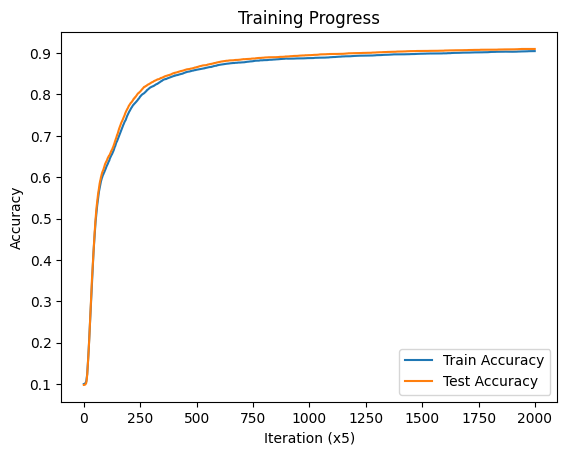

In [33]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01)
max_iter = 10000

history = {
    "losses": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "weights_layer_1": [],
    "weights_layer_2": []
}

for i in range (max_iter):
    if i % 5 == 4:
        save = True
    else:
        save = False
    step(model, train_images, train_labels, test_images, test_labels, opt, loss_fn, save, history)

    if save:
        clear_output(wait=True)
        plt.plot(history["train_accuracy"], label="Train Accuracy")
        plt.plot(history["test_accuracy"], label="Test Accuracy")
        plt.xlabel("Iteration (x5)")
        plt.ylabel("Accuracy")
        plt.title("Training Progress")
        plt.legend()
        plt.show()

In [34]:
print(history['test_accuracy'][-1])

0.9101


Точность в районе 90%

Для более глубокого понимания работы нейросети визуализируйте матрицы весов для нескольких итераций обучения. Тем самым, вы сможете оценить, как меняется поведение модели в процессе обучения.

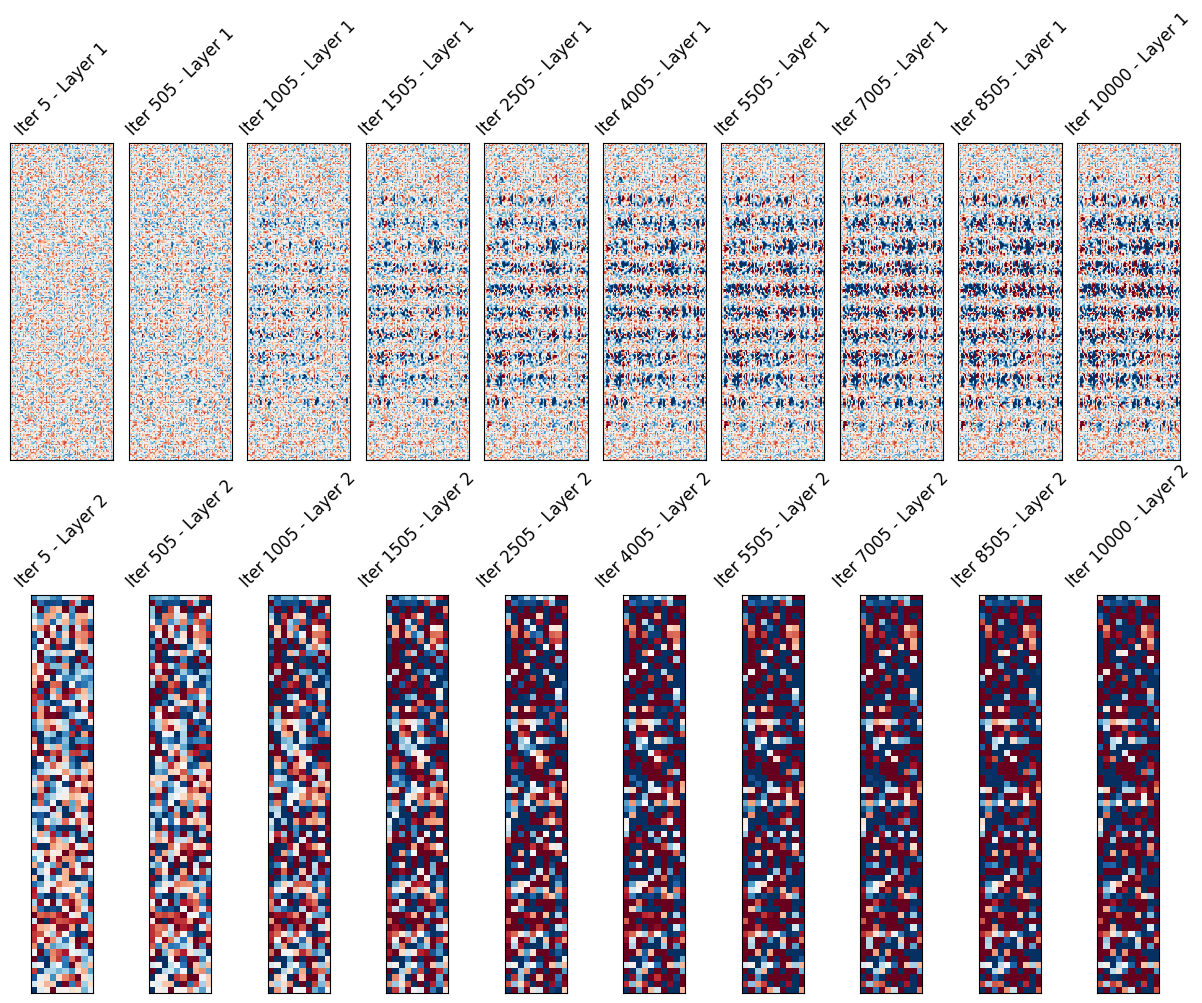

In [35]:
iter = [0, 100, 200, 300, 500, 800, 1100, 1400, 1700, 1999]


plt.figure(figsize=(12, 10))

for i, iter_num in enumerate(iter):

    weights_layer_1 = history["weights_layer_1"][iter_num]

    plt.subplot(2, len(iter), i + 1)
    plt.imshow(weights_layer_1.T, cmap="RdBu", vmin=-0.1, vmax=0.1)
    plt.title(f"Iter {iter_num * 5 + 5} - Layer 1", rotation=45)
    plt.xticks([])
    plt.yticks([])

    weights_layer_2 = history["weights_layer_2"][iter_num]

    plt.subplot(2, len(iter), len(iter) + i + 1)
    plt.imshow(weights_layer_2.T, cmap="RdBu", vmin=-0.1, vmax=0.1)
    plt.title(f"Iter {iter_num * 5 + 5} - Layer 2", rotation=45)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

Сначала визуализации выглядят хаотично, потом (начиная с 1000 итерации примерно) в них появляется некая система, начинают выделяться кусочки с отрицательными весами, и с каждым разом они становятся всё более и более явными. Я думаю, что это места, где у цифр бывают углы, изгибы и тп (то по чему можно определить цифру). В целом места расположений этих скоплений довольно обоснованы (оси симметрии на тех графиках это центр изначального изображения).
На втором слое сначала тоже хаотично, потом появляется система, которая выглядит сложнее, чем у первого слоя (например линии, штука, которая на сердечко на боку похожа немного..). Второй слой работает с комбинациями признаков, так что логично, что в этом случае зависимости сложнее.

Попробуйте улучшить точность классификации, рассмотрев больше нейронов в промежуточном слое.

In [36]:
model = nn.Sequential(
    nn.Linear(14 * 14, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

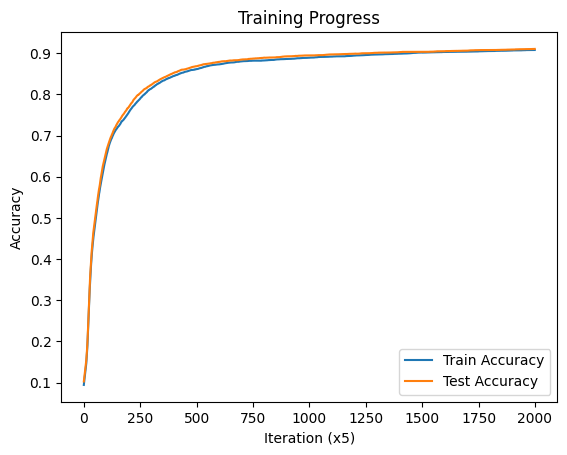

In [37]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01)
max_iter = 10000

history = {
    "losses": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "weights_layer_1": [],
    "weights_layer_2": []
}

for i in range (max_iter):
    if i % 5 == 4:
        save = True
    else:
        save = False
    step(model, train_images, train_labels, test_images, test_labels, opt, loss_fn, save, history)

    if save:
        clear_output(wait=True)
        plt.plot(history["train_accuracy"], label="Train Accuracy")
        plt.plot(history["test_accuracy"], label="Test Accuracy")
        plt.xlabel("Iteration (x5)")
        plt.ylabel("Accuracy")
        plt.title("Training Progress")
        plt.legend()
        plt.show()

In [38]:
print(history['test_accuracy'][-1])

0.9106


Теперь попробуйте добавить к сети еще один слой.

In [39]:
model = nn.Sequential(
    nn.Linear(14 * 14, 128), 
    nn.ReLU(),
    nn.Linear(128, 64), 
    nn.ReLU(),
    nn.Linear(64, 10)
)

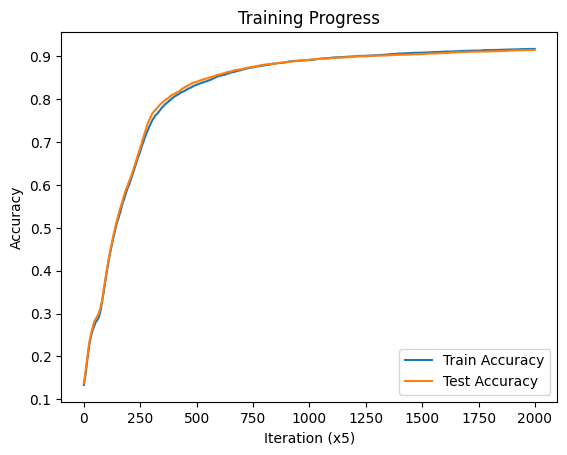

In [40]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01)
max_iter = 10000

history = {
    "losses": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "weights_layer_1": [],
    "weights_layer_2": []
}

for i in range (max_iter):
    if i % 5 == 4:
        save = True
    else:
        save = False
    step(model, train_images, train_labels, test_images, test_labels, opt, loss_fn, save, history)

    if save:
        clear_output(wait=True)
        plt.plot(history["train_accuracy"], label="Train Accuracy")
        plt.plot(history["test_accuracy"], label="Test Accuracy")
        plt.xlabel("Iteration (x5)")
        plt.ylabel("Accuracy")
        plt.title("Training Progress")
        plt.legend()
        plt.show()

In [41]:
print(history['test_accuracy'][-1])

0.9148


Насколько дольше обучается нейросеть? Получилось ли улучшить качество?


Точность изначальной модели 0.9101, после добавления большего количества нейронов точность стала 0.9106. После добавления нового слоя до 0.9148. Время работы соответственно ~11 минут, ~20 минут, ~22 минуты. Качество в целом улучшается, но очень незначительно. В случае новых нейронов это 0.05%, мне кажется, вообще можно на погрешность списать. Если добавить слой, то качество улучшается примерно на полпроцента. Но время работы увеличивается почти в два раза.


Обучение нейросетей действительно происходит. Это видно о графикам точности. Модели не слишком сильно переобучаются, потому что точности на тестовой и тренировочной выборке примерно одинаковые. По матрицам весов тоже видно, что модели обучаются, сначала веса хаотичные, а потом появляются зависимости. Если создавать дополнительные нейроны, то качество увеличивается не очень сильно, если добавить дополнительный слой, то точность растет, но тоже не очень сильно, но время обучения увеличивается значительно. Мне кажется, что чтобы значительно увеличить точности, нужно как-то преобрабатывать данные.